In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

print("Libraries loaded as expected")

Libraries loaded as expected


In [2]:
df = pd.read_csv('Planetary_data.csv', comment='#')
df.head(3)

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826


In [7]:
## Exploring planets with two stars i.e. binary planets.

binary_stars = df['sy_snum'].value_counts()
print(binary_stars)

sy_snum
1    5724
2     488
3      73
4       1
Name: count, dtype: int64


<Axes: ylabel='count'>

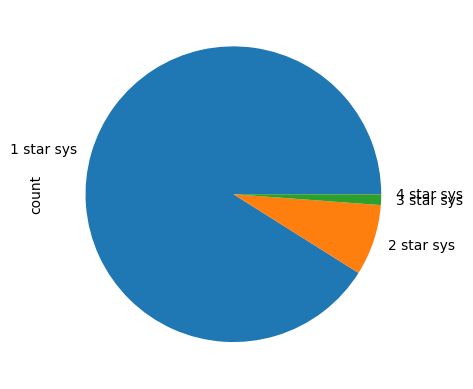

In [13]:
binary_stars.plot.pie(labels=['1 star sys', '2 star sys', '3 star sys', '4 star sys'])

<Axes: ylabel='Frequency'>

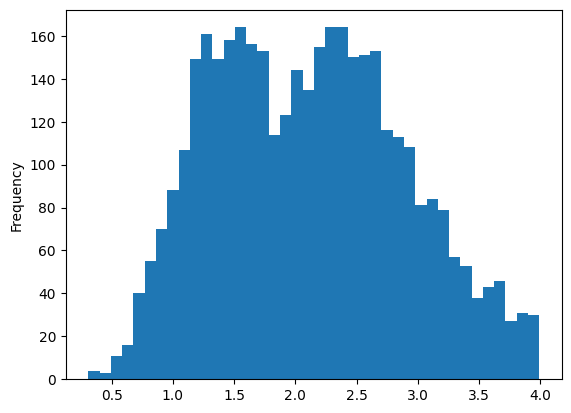

In [29]:
### radius valley. Finding planets of earth 1.5 to 2.0 is extremely rare because of atmosphere boiling.

rad_data = df['pl_rade'] < 4
earth_size_plnts = np.where( rad_data == True )

data = df[rad_data]
data['pl_rade'].plot(kind='hist', bins=40)

<Axes: xlabel='st_teff', ylabel='st_mass'>

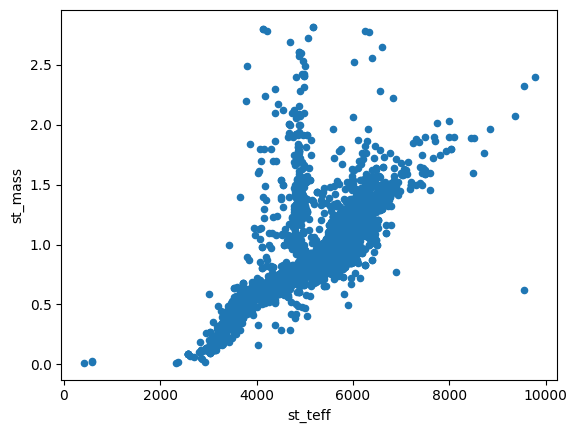

In [44]:
### Heavy stars burn brighter.

fam_seq_data = df.dropna(subset=['st_mass', 'st_teff']).copy()
mask = (fam_seq_data['st_mass'] < 3.0) & (fam_seq_data['st_teff'] < 10000)

filtered_data = fam_seq_data[mask]
filtered_data.plot(kind='scatter', x='st_teff', y='st_mass')